/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

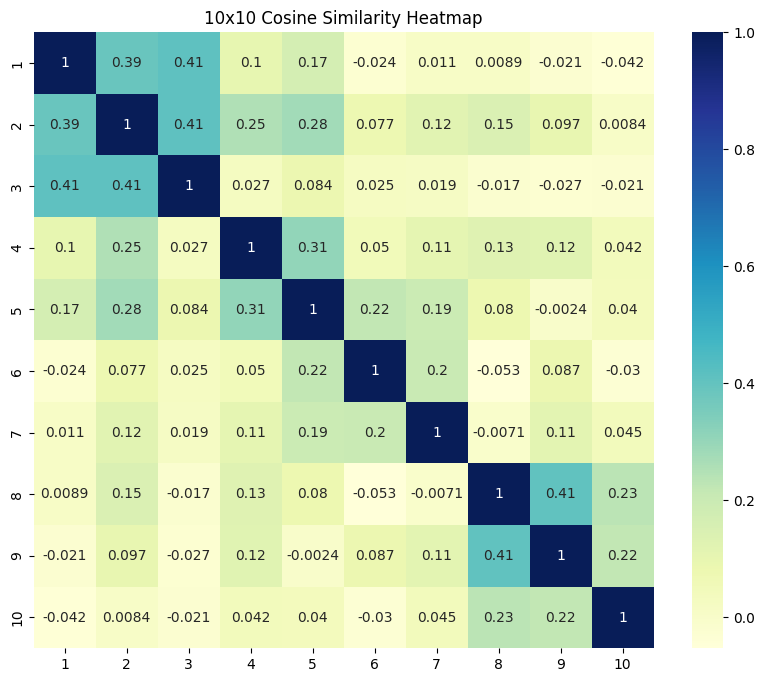


Query: The bowler took three wickets in one over
------------------------------
Sentence: The batsman hit a massive six over the long-on boundary.
Similarity Score: 0.5319

Sentence: Fast bowlers often use the new ball to get extra swing.
Similarity Score: 0.4997



In [ ]:
# Install required libraries
!pip install sentence-transformers seaborn matplotlib pandas -q

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# 1. Define 10 sentences across 3 topics
sentences = [
    "The batsman hit a massive six over the long-on boundary.", # Cricket
    "Fast bowlers often use the new ball to get extra swing.", # Cricket
    "The umpire signaled a wide after the ball passed the leg side.", # Cricket
    "Indian spices add a rich depth of flavor to every curry.", # Cooking
    "Slow-cooking the meat ensures it stays tender and juicy.", # Cooking
    "Always preheat your oven before baking a sourdough loaf.", # Cooking
    "Whisk the egg whites until they form stiff, glossy peaks.", # Cooking
    "Two-factor authentication adds a vital layer of account security.", # Cybersecurity
    "Phishing emails often trick users into revealing their passwords.", # Cybersecurity
    "Firewalls block unauthorized access to private computer networks."  # Cybersecurity
]

# 2. Generate embeddings using all-MiniLM-L6-v2
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

# 3. Compute and display 10x10 Cosine Similarity Matrix
cosine_scores = util.cos_sim(embeddings, embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores.tolist(), annot=True, cmap='YlGnBu',
            xticklabels=range(1,11), yticklabels=range(1,11))
plt.title("10x10 Cosine Similarity Heatmap")
plt.show()

# 4. Find top 2 similar sentences for the new query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity between query and the 10 sentences
results = util.cos_sim(query_embedding, embeddings)[0]

# Get top 2 indices
top_results = results.argsort(descending=True)[:2]

print(f"\nQuery: {query}")
print("-" * 30)
for idx in top_results:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {results[idx]:.4f}\n")
